In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#Número de agentes
N = 10_000
#Dinero inicial
m_0 = 100
#Vector de agentes
M = np.ones(N)*m_0



In [ ]:
#Seleccionar dos agentes
def asig():
  count = 0
  while count == 0:
    x = np.random.randint(0,N,2)
    if x[0] != x[1]:
      count = 1
  return x

In [ ]:
count2 = 0 #contador de simulaciones
# Interacción entre agentes
while count2 < 1e6:
  i,j = asig()
  delm = 0.25*M[j] #alfa = 0.25
  M[i] += delm
  M[j] -= delm
  count2 += 1


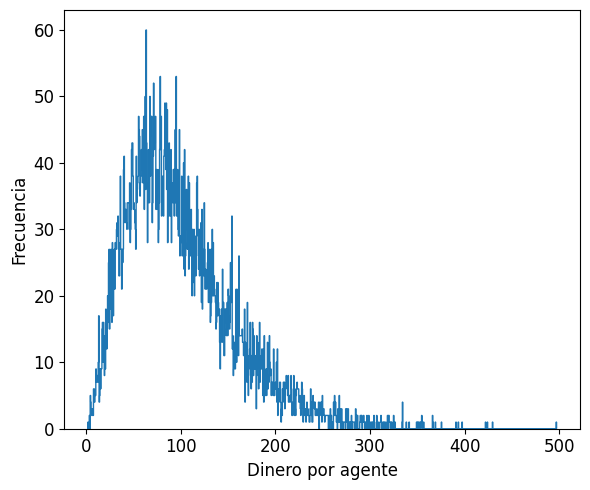

In [ ]:
#Obtener datos de las frecuencias
datos = pd.read_csv("Dinero_modelo_mul_10_10_sim.txt", header=None)
ydata = datos[0]

# Crear histograma
plt.figure(figsize=(6,5))
plt.hist(ydata, bins=1000, histtype='step')
plt.xlabel('Dinero por agente', fontsize = 12)
plt.ylabel('Frecuencia', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("histomula.jpg", dpi=300)
plt.show()


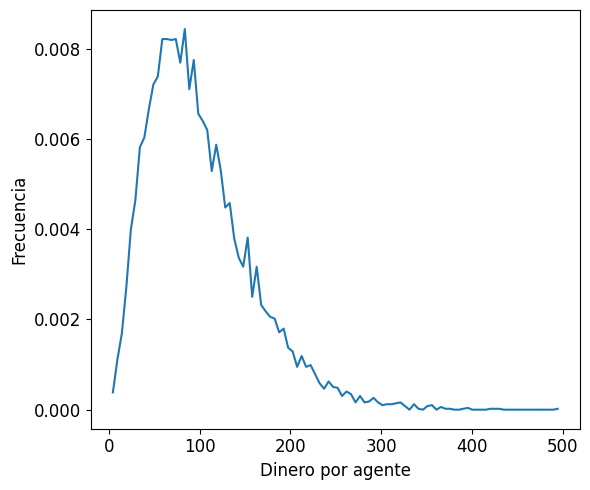

0.9999999999999999


In [ ]:
#Normalizar el histograma
hist, bin_edges = np.histogram(ydata, bins=100)
dx = bin_edges[1] - bin_edges[0]
c = np.sum(hist * dx) #constante de normalizacion
ydata_norm = hist / c
bins = bin_edges[:-1]
bins_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(6,5))
plt.plot(bins_centers, ydata_norm)
plt.xlabel('Dinero por agente', fontsize = 12)
plt.ylabel('Frecuencia', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("histomulanorm.jpg", dpi=300)
plt.show()

#Comprobar la normalizacion
print(np.sum(ydata_norm*dx))


In [ ]:
#Calculando la entropia
def Fun_entropia(y,c,x):
  total = 0
  for i in range(len(x)-1):
    total += (x[i+1]-x[i]) * (y[i+1]/c) * (-np.log(y[i+1]))
  return np.log(c) + total

c = np.sum(hist * dx)
S = Fun_entropia(ydata,c,bins_centers)
#S_continuo = S + np.log(dx)

print(S)


5.863982434064109


In [ ]:
#Otra forma de calcular la entropia (no depende tanto del ancho del bin)
from scipy.stats import gaussian_kde
kde = gaussian_kde(ydata)
xs = np.linspace(min(ydata), max(ydata), 135)
p = kde(xs)
H = -np.sum(p * np.log(p)) * (xs[1]-xs[0])
H

np.float64(5.363991749375244)

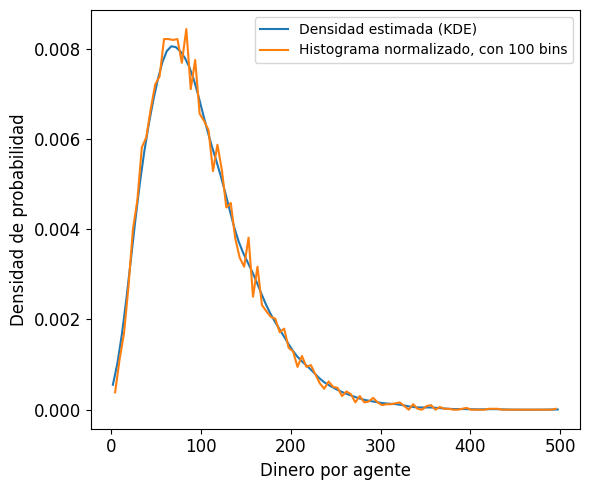

In [ ]:
#Grafica del histograma normalizado y una funcion PDF estimada
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Crear el KDE
kde = gaussian_kde(ydata)

# Puntos donde evaluaremos la densidad
xs = np.linspace(min(ydata), max(ydata), 100)

# Evaluar la densidad
p = kde(xs)

# Graficar
plt.figure(figsize=(6,5))
plt.plot(xs, p, label='Densidad estimada (KDE)')
plt.plot(bins_centers, ydata_norm, label = 'Histograma normalizado, con 100 bins')
plt.xlabel('Dinero por agente', fontsize = 12)
plt.ylabel('Densidad de probabilidad',  fontsize = 12)
plt.legend()
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("densKDE.jpg", dpi=300)
plt.show()

In [ ]:
#Calculamos la entropia para sistintos valores de m_0
import numpy as np
import pandas as pd
#importamos datos de 100 simulaciones con m_0 = np.linspace(10,1000,100)
datos_vec = pd.read_csv("Dinero_modelo_varios_m.txt", header=None, delim_whitespace=True)
filas, columnas = datos_vec.shape

#Calcular la entropia para las 100 simulaciones
S_vector = np.zeros(columnas)
for i in range(columnas):
    a = datos_vec.iloc[:,i].to_numpy()
    kde = gaussian_kde(a)
    xs = np.linspace(min(a), max(a), 135)
    p = kde(xs)
    H = -np.sum(p * np.log(p)) * (xs[1]-xs[0])
    S_vector[i] = H

/tmp/ipython-input-722379307.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  datos_vec = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Simulacion (Jhony)/Dinero_modelo_varios_m.txt", header=None, delim_whitespace=True)


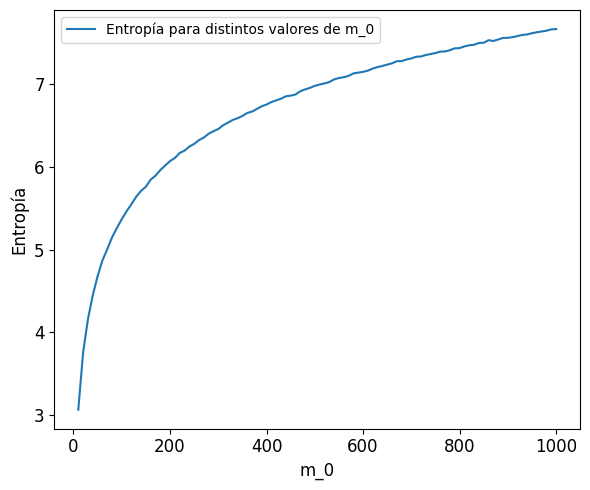

In [ ]:
#Grafica
m0_vector = np.linspace(10,1000,100) #vector de dinero
h = m0_vector[1] - m0_vector[0]

plt.figure(figsize=(6,5))
plt.plot(m0_vector,S_vector, label = 'Entropía para distintos valores de m_0')
plt.xlabel('m_0', fontsize = 12)
plt.ylabel('Entropía', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("entromul.jpg", dpi=300)
plt.show()


S= (0.9962 ± 0.0006)*In(m0) + (0.7793 ± 0.0037)


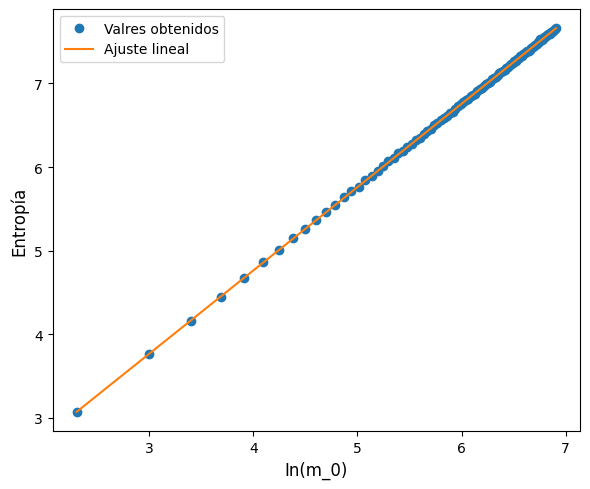

[2.30258509 2.99573227 3.40119738 3.68887945 3.91202301 4.09434456
 4.24849524 4.38202663 4.49980967 4.60517019 4.70048037 4.78749174
 4.86753445 4.94164242 5.01063529 5.07517382 5.13579844 5.19295685
 5.24702407 5.29831737 5.34710753 5.39362755 5.43807931 5.48063892
 5.52146092 5.56068163 5.59842196 5.6347896  5.66988092 5.70378247
 5.7365723  5.768321   5.79909265 5.82894562 5.85793315 5.88610403
 5.91350301 5.94017125 5.96614674 5.99146455 6.01615716 6.04025471
 6.06378521 6.08677473 6.10924758 6.13122649 6.15273269 6.1737861
 6.19440539 6.2146081  6.23441073 6.25382881 6.27287701 6.29156914
 6.30991828 6.32793678 6.34563636 6.3630281  6.38012254 6.39692966
 6.41345896 6.42971948 6.44571982 6.46146818 6.47697236 6.49223984
 6.50727771 6.5220928  6.5366916  6.55108034 6.56526497 6.57925121
 6.59304453 6.60665019 6.62007321 6.63331843 6.64639051 6.65929392
 6.67203295 6.68461173 6.69703425 6.70930434 6.7214257  6.73340189
 6.74523635 6.75693239 6.76849321 6.77992191 6.79122146 6.80239

In [ ]:
# Ajuste lineal S= c*In(m0) + d
m0_vectorlog = np.log(m0_vector)
coef_s, cov_s = np.polyfit(m0_vectorlog, S_vector, 1, cov=True)
c, d = coef_s
err_c, err_d = np.sqrt(np.diag(cov_s))  # errores estándar

print(f"S= ({c:.4f} ± {err_c:.4f})*In(m0) + ({d:.4f} ± {err_d:.4f})")

S_fitlog = c * m0_vectorlog + d

plt.figure(figsize=(6,5))
plt.plot(m0_vectorlog, S_vector, 'o', label='Valres obtenidos')
plt.plot(m0_vectorlog, S_fitlog, '-', label='Ajuste lineal')
plt.xlabel('In(m_0)', fontsize = 12)
plt.ylabel('Entropía', fontsize = 12)
plt.legend()
plt.tight_layout()
plt.savefig("entromulajuste.jpg", dpi=300)
plt.show()
print(m0_vectorlog)

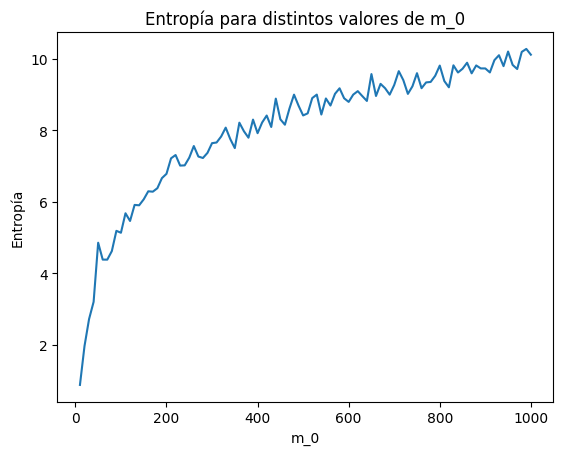

In [ ]:
#Usando el histograma para calcular la entropia
S_vector2 = np.zeros(columnas)
for i in range(columnas):
    a = datos_vec.iloc[:,i].to_numpy()
    hist, bin_edges = np.histogram(a, bins=135)
    dx = bin_edges[1] - bin_edges[0]
    c = np.sum(hist * dx) #constante de normalizacion
    bins_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


    S = Fun_entropia(ydata,c,bins_centers)
    S_continuo = S + np.log(dx)
    S_vector2[i] = S_continuo

m0_vector = np.linspace(10,1000,100)

plt.plot(m0_vector,S_vector2)
plt.xlabel('m_0')
plt.ylabel('Entropía')
plt.title('Entropía para distintos valores de m_0')
plt.show()

In [ ]:
import numpy as np

def derivada_5puntos(S_vector, h):
    N = len(S_vector)
    dS = np.zeros(N)

    # Bordes (2 primeros puntos) → diferencias hacia adelante
    dS[0] = (-25*S_vector[0] + 48*S_vector[1] - 36*S_vector[2] + 16*S_vector[3] - 3*S_vector[4]) / (12*h)
    dS[1] = (-3*S_vector[0] - 10*S_vector[1] + 18*S_vector[2] - 6*S_vector[3] + S_vector[4]) / (12*h)

    # Puntos interiores → fórmula centrada
    for i in range(2, N-2):
        dS[i] = (-S_vector[i+2] + 8*S_vector[i+1] - 8*S_vector[i-1] + S_vector[i-2]) / (12*h)

    # Bordes finales (2 últimos puntos) → diferencias hacia atrás
    dS[-2] = (-S_vector[-5] + 6*S_vector[-4] - 18*S_vector[-3] + 10*S_vector[-2] + 3*S_vector[-1]) / (12*h)
    dS[-1] = (3*S_vector[-5] - 16*S_vector[-4] + 36*S_vector[-3] - 48*S_vector[-2] + 25*S_vector[-1]) / (12*h)

    return dS

T_inv = derivada_5puntos(S_vector, h) #1/ T = dS/dU = dS/dm_0
T = 1 / T_inv


/tmp/ipython-input-3580344270.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


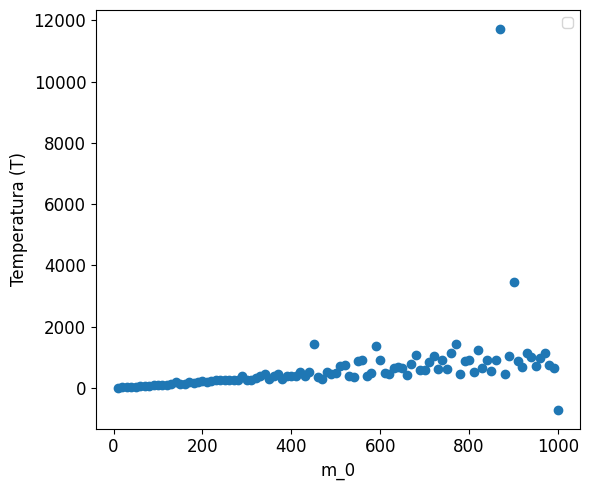

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(m0_vector,T)
plt.xlabel('m_0', fontsize = 12)
plt.ylabel('Temperatura (T)', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("temperaturamul.jpg", dpi=300)
plt.show()


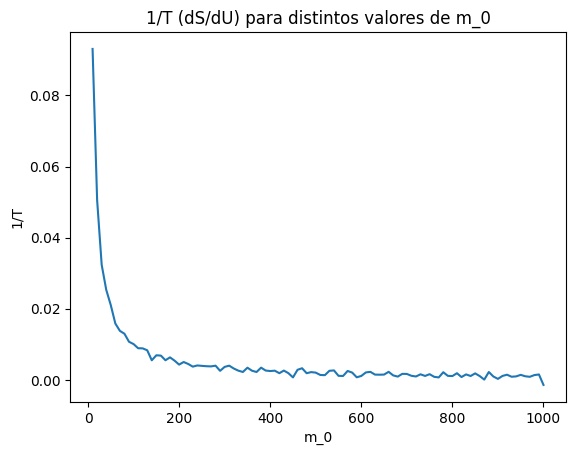

In [ ]:
plt.plot(m0_vector,T_inv)
plt.xlabel('m_0')
plt.ylabel('1/T')
plt.title('1/T (dS/dU) para distintos valores de m_0')
plt.show()

T = (1.0183 ± 0.0516)*m0 + (0.0421 ± 12.1494)


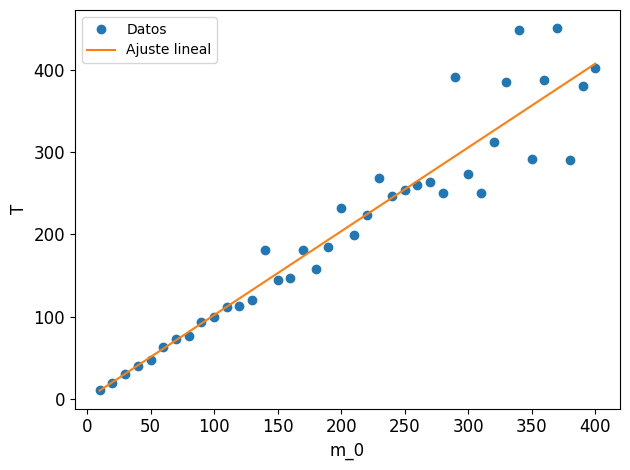

[ 10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140.
 150. 160. 170. 180. 190. 200. 210. 220. 230. 240. 250. 260. 270. 280.
 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 390. 400.]


In [ ]:
# Ajuste lineal T = a*m0 + b
coef, cov = np.polyfit(m0_vector[0:40], T[0:40], 1, cov=True)
a, b = coef
err_a, err_b = np.sqrt(np.diag(cov))  # errores estándar

print(f"T = ({a:.4f} ± {err_a:.4f})*m0 + ({b:.4f} ± {err_b:.4f})")

T_fit = a * m0_vector



plt.plot(m0_vector[0:40], T[0:40], 'o', label='Datos')
plt.plot(m0_vector[0:40], T_fit[0:40], '-', label='Ajuste lineal')
plt.xlabel('m_0', fontsize = 12)
plt.ylabel('T', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("ajustetem.jpg", dpi=300)
plt.show()
print(m0_vector[0:40])

T = (1.0099 ± 0.1311)*m0 + (31.8481 ± 75.8009)


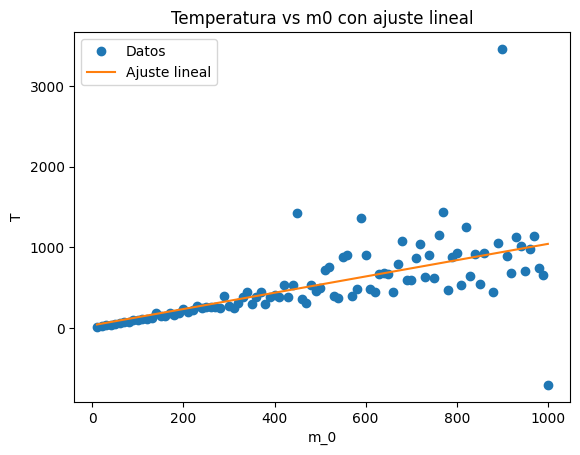

In [ ]:
# Ajuste lineal T = a*m0 + b
m0_vector2 = np.delete(m0_vector, T.argmax())
T2 = np.delete(T, T.argmax())

coef2, cov2 = np.polyfit(m0_vector2, T2, 1, cov=True)
a2, b2 = coef2
err_a2, err_b2 = np.sqrt(np.diag(cov2))  # errores estándar

print(f"T = ({a2:.4f} ± {err_a2:.4f})*m0 + ({b2:.4f} ± {err_b2:.4f})")

T_fit2 = a2 * m0_vector2 + b2

plt.plot(m0_vector2, T2, 'o', label='Datos')
plt.plot(m0_vector2, T_fit2, '-', label='Ajuste lineal')
plt.xlabel('m_0')
plt.ylabel('T')
plt.title('Temperatura vs m0 con ajuste lineal')
plt.legend()
plt.show()



$$T = m_0 \pm δ_T$$,
y
$$ S = In(m_0) + 0.77 ±  δ_S$$.
Por lo que
$$ C = T\frac{\partial S}{\partial T} = m_0\frac{1}{m_0}  = 1$$

In [ ]:
def Lorentz(array):
    dinero = np.asarray(array, dtype=np.float64)
    n = array.shape[0] #número de agentes
    M_s = np.sort(dinero) #ordenamos las cantidades de dinero por agente
    y = np.cumsum(M_s)/(n*100) #obtenemos la porcion de dinero acumulado
    x = np.linspace(0,1,n)
    return x,y

def integral(x,y):
    total = 0
    for i in range(len(x)-1):
        total += (x[i+1]-x[i])*(y[i+1])
    return total

In [ ]:
#Promedio y desviacion estandar del indice de Gini
#Obtener datos de las frecuencias de 100 simulaciones
simulaciones = pd.read_csv(
  "Dinero_100_simulaciones_multiplicativo.txt",
    header=None, delim_whitespace=True)
filas, columnas = simulaciones.shape #10_000 x 100

#Calculamos el indice de Gini para las 100 simulaciones
G_vector = np.zeros(columnas)
for i in range(columnas):
    x, y = Lorentz(simulaciones.iloc[:, i].to_numpy())

    G_vector[i] = 1 - 2*integral(x,y)

#Promedio y desviacion estandar
promedio_gini = np.mean(G_vector)
desviacion_gini = np.std(G_vector)

print(f"Promedio del índice de Gini: {promedio_gini}")
print(f"Desviación estándar del índice de Gini: {desviacion_gini}")

/tmp/ipython-input-3025774962.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  simulaciones = pd.read_csv(


Promedio del índice de Gini: 0.31238264084682466
Desviación estándar del índice de Gini: 0.002116916135972496


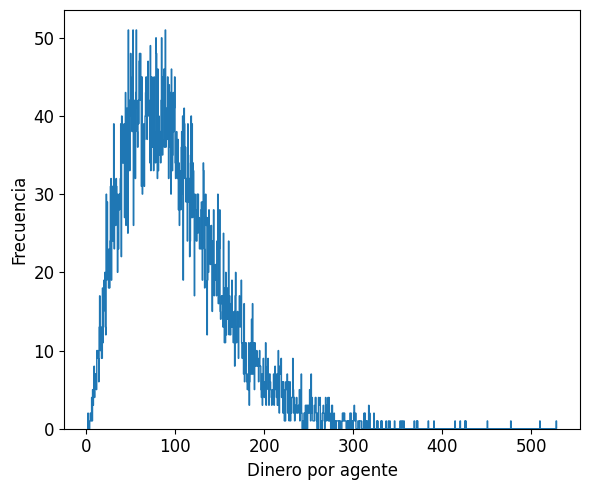

In [ ]:
plt.figure(figsize=(6,5))
plt.hist(simulaciones.iloc[:, 99], bins=1000, histtype='step')
plt.xlabel('Dinero por agente', fontsize = 12)
plt.ylabel('Frecuencia', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("histomula.jpg", dpi=300)
plt.show()